## From model to production

We're going to use a computer vision example to look at the end-to-end process of creating a deep learning application. More specifically, we're going to build a bear classifier! In the process, we'll discuss the capabilities and constraints of deep learning, explore how to create datasets, look at possible gotchas when using deep learning in practice, and more

## The practice of Deep Learning

When implementing deep learning in practical applications, it's crucial to set realisti expectations rather than viewing it as a magical solution.

Our approach to these models involves two primary considerations:

- **Constraints**: These arise from various factors, including the quality and volume of available data, computational resources, the inherent complexity of the problem, and real-world ethical or security concerns
*(ex. A model trained only on daytime photos will not be able to "see" at night.)*

- **Capabilities**: This refers to a model's ability to discern intricate patterns from limited data, automate repetitive actions and apply learned knowledge to make predictions on unseen data.
*(ex. Recognizing a disease from an X-ray better than an inexperienced eye or finding hidden correlations between chemical variables in a wine.)*

The best thing to do is to keep an open mind. If you remain open to the possibility that deep learning might solve part of your problem with less data or complexity than you expect, then it is possible to design a process where you can find the specific capabilities and constraints related to your particular problem as you work through the process.



## Starting your project

When selecting a project, the most important consideration is data availability. The goal is not to find the perfect dataset or project, but just to get started and iterate from there.

It is recommended to iterate from end to end in your project, meaning that you should first complete every step as well as you can in a reasonable amount of time, all the way to the end. For instance, if your final goal is an application that runs on a mobile phone, then that should be what you have after each iteration.

When you are just starting out with deep learning, it's not a good idea to branch out into very different areas, to places that deep learning has not been applied to before. That's because if your model doesn't work at first, you will not know whether it is because you have made a mistake, or if the very problem you are trying to solve is simply not solvable with deep learning.

So, it is best at first to start with something where you can find an example online.

In [9]:
from fastai.vision.all import *

from fastbook import *

from fastai.vision.widgets import *

path = "/home/davidebui/DeepLearning/Lesson2/Bear_dataset"
bear_types = 'grizzly','teddy','polar','black', 'panda'

bears = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),
    get_y = parent_label,
    item_tfms = Resize(128)
)

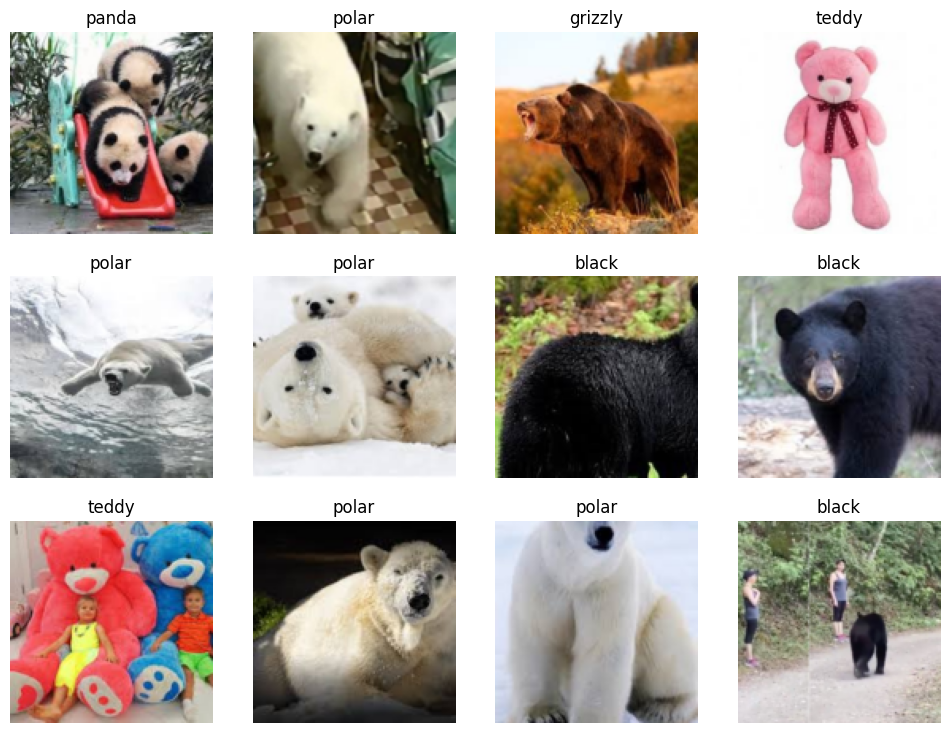

In [4]:
dls = bears.dataloaders(path)
dls.show_batch(max_n = 12)

In [11]:

failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[]

In [ ]:
learn = vision_learner(dls, resnet18, metrics = error_rate)
learn.fine_tune(4)